# DSA 210 — ML Phase: Day 4
## Final Model Selection & Summary

**Bedirhan Ceylan** — Spring 2026

Day 3 identified Random Forest as the best-performing model (Test ROC-AUC 0.741, CV ROC-AUC 0.708 ± 0.040). Day 4 finalizes the model: refits Random Forest on the full dataset, computes per-fold metrics for the final summary table, runs permutation importance for a more reliable ranking than impurity-based importance, and persists the model to disk.

## 1. Setup & Load Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

data = pd.read_csv('../data/sollen_tasks_features.csv')
y = data['is_delayed']
X = data.drop(columns=['is_delayed'])

categorical_features = ['task_category', 'assigned_to', 'creation_day']
numeric_features = [c for c in X.columns if c not in categorical_features]

print(f"Loaded: {data.shape[0]} rows, {len(X.columns)} features")
print(f"Class balance: {y.mean()*100:.1f}% delayed")

Loaded: 486 rows, 10 features
Class balance: 34.8% delayed


## 2. Final Model: Random Forest

Selected based on Day 3 results — highest test ROC-AUC (0.741), best CV ROC-AUC (0.708), and competitive across all metrics. Same hyperparameters as Day 3.

In [2]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

final_model = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("Final model pipeline:")
print(final_model)

Final model pipeline:
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['task_category',
                                                   'assigned_to',
                                                   'creation_day']),
                                                 ('num', StandardScaler(),
                                                  ['creation_month_num',
                                                   'is_weekend_creation',
                                                   'title_word_count',
                                                   'team_total_load_at_creation',
                                                   'developer_workload_at_creation',
                                                   'dev_historical_delay_rate',
                                                   'dev_avg_pas

## 3. Per-Fold CV Metrics

For the final summary, we report metrics fold-by-fold rather than just mean ± std. This shows how stable the model is across different data splits.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

fold_df = pd.DataFrame({metric: cv_results[f'test_{metric}'] for metric in scoring})
fold_df.index = [f'Fold {i+1}' for i in range(5)]
fold_df.loc['Mean'] = fold_df.mean()
fold_df.loc['Std'] = fold_df.iloc[:5].std()

print("Random Forest — per-fold CV metrics:\n")
print(fold_df.round(3).to_string())

Random Forest — per-fold CV metrics:

        accuracy  precision  recall     f1  roc_auc
Fold 1     0.663      0.516   0.471  0.492    0.754
Fold 2     0.691      0.538   0.636  0.583    0.747
Fold 3     0.680      0.552   0.471  0.508    0.690
Fold 4     0.680      0.565   0.382  0.456    0.697
Fold 5     0.649      0.500   0.529  0.514    0.643
Mean       0.673      0.534   0.498  0.511    0.706
Std        0.016      0.026   0.094  0.046    0.045


## 4. Train/Test Evaluation

Same 80/20 split as Days 2-3 for direct comparability.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples\n")
print("Test classification report:")
print(classification_report(y_test, y_pred, target_names=['on_time', 'delayed']))
print(f"Test ROC-AUC: {test_auc:.3f}")

Train: 388 samples | Test: 98 samples

Test classification report:
              precision    recall  f1-score   support

     on_time       0.76      0.83      0.79        64
     delayed       0.61      0.50      0.55        34

    accuracy                           0.71        98
   macro avg       0.68      0.66      0.67        98
weighted avg       0.71      0.71      0.71        98

Test ROC-AUC: 0.741


## 5. Final Confusion Matrix

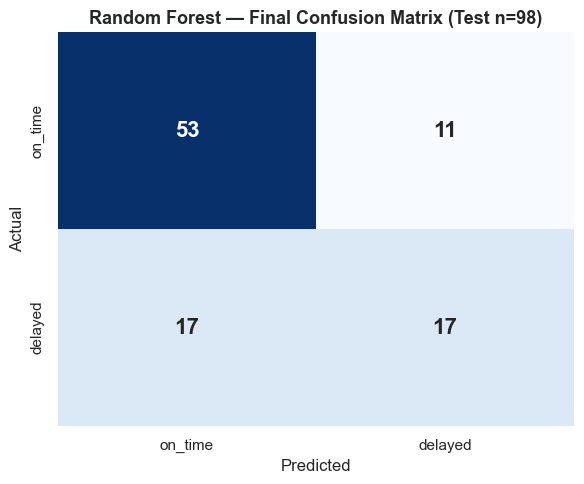

True Positives:  17 (correctly predicted delays)
True Negatives:  53 (correctly predicted on-time)
False Positives: 11 (predicted delay, was on-time)
False Negatives: 17 (predicted on-time, was delayed)


In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['on_time', 'delayed'], yticklabels=['on_time', 'delayed'],
            annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title('Random Forest — Final Confusion Matrix (Test n=98)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/20_final_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives:  {tp} (correctly predicted delays)")
print(f"True Negatives:  {tn} (correctly predicted on-time)")
print(f"False Positives: {fp} (predicted delay, was on-time)")
print(f"False Negatives: {fn} (predicted on-time, was delayed)")

## 6. Final ROC and Precision-Recall Curves

ROC and PR curves side-by-side. PR curve is more informative for imbalanced classes.

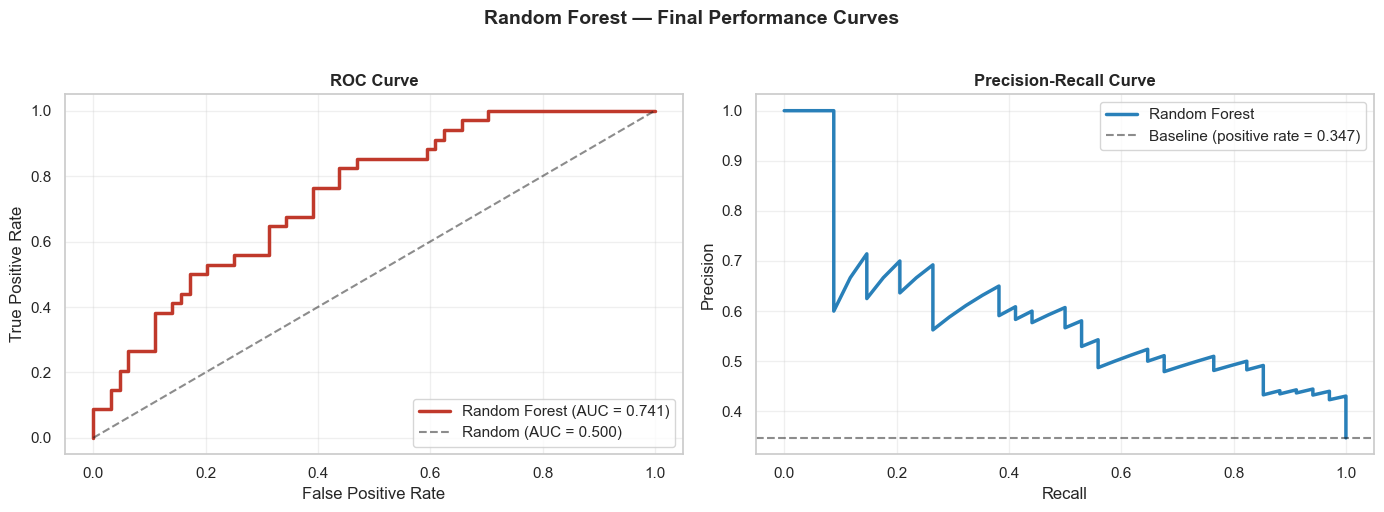

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, linewidth=2.5, color='#c0392b', label=f'Random Forest (AUC = {test_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
baseline_pr = y_test.mean()
axes[1].plot(recall, precision, linewidth=2.5, color='#2980b9', label='Random Forest')
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5,
                label=f'Baseline (positive rate = {baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.suptitle('Random Forest — Final Performance Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/21_final_curves.png', bbox_inches='tight')
plt.show()

## 7. Permutation Importance

Impurity-based importance (used in Day 3) can be biased toward high-cardinality features. Permutation importance is more reliable: it measures how much the model's score drops when each feature is randomly shuffled. Computed on the test set.

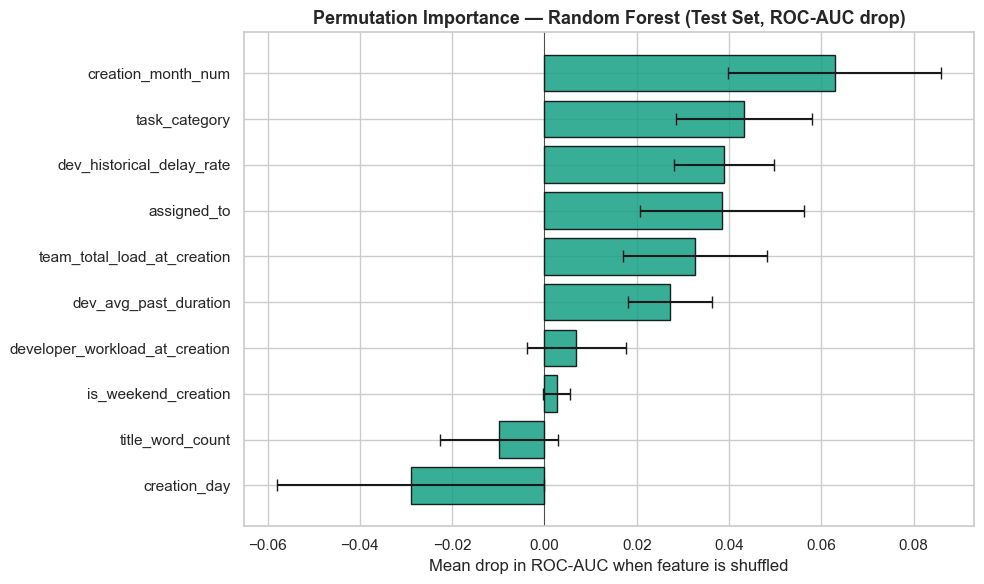


Permutation importance ranking:

                       feature  importance_mean  importance_std
            creation_month_num           0.0629          0.0230
                 task_category           0.0432          0.0147
     dev_historical_delay_rate           0.0389          0.0109
                   assigned_to           0.0385          0.0178
   team_total_load_at_creation           0.0326          0.0156
         dev_avg_past_duration           0.0272          0.0091
developer_workload_at_creation           0.0069          0.0107
           is_weekend_creation           0.0027          0.0029
              title_word_count          -0.0098          0.0127
                  creation_day          -0.0290          0.0289


In [7]:
perm_result = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'],
        color='#16a085', alpha=0.85, edgecolor='black', capsize=4)
ax.set_title('Permutation Importance — Random Forest (Test Set, ROC-AUC drop)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean drop in ROC-AUC when feature is shuffled')
ax.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.savefig('../plots/22_permutation_importance.png', bbox_inches='tight')
plt.show()

print("\nPermutation importance ranking:\n")
print(perm_df.sort_values('importance_mean', ascending=False).round(4).to_string(index=False))

## 8. Final Model Comparison Table

A clean summary suitable for the README and the final report. Test ROC-AUC values come from a single 80/20 stratified split (random_state=42); CV ROC-AUC is mean ± std across 5 stratified folds.

In [8]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'kNN (k=5)',
              'Gradient Boosting', 'Random Forest'],
    'CV ROC-AUC': ['0.577 ± 0.039', '0.582 ± 0.030', '0.662 ± 0.050',
                   '0.684 ± 0.033', '0.708 ± 0.040'],
    'Test ROC-AUC': [0.639, 0.573, 0.710, 0.725, 0.741],
    'Test Accuracy': [0.62, 0.60, 0.70, 0.71, 0.71],
    'Test F1 (delayed)': [0.53, 0.47, 0.47, 0.48, 0.55],
}).set_index('Model')

print("Final model comparison:\n")
print(summary.to_string())

summary.to_csv('../data/model_comparison.csv')
print("\nSaved: ../data/model_comparison.csv")

Final model comparison:

                        CV ROC-AUC  Test ROC-AUC  Test Accuracy  Test F1 (delayed)
Model                                                                             
Logistic Regression  0.577 ± 0.039         0.639           0.62               0.53
Decision Tree        0.582 ± 0.030         0.573           0.60               0.47
kNN (k=5)            0.662 ± 0.050         0.710           0.70               0.47
Gradient Boosting    0.684 ± 0.033         0.725           0.71               0.48
Random Forest        0.708 ± 0.040         0.741           0.71               0.55

Saved: ../data/model_comparison.csv


## 9. Persist Final Model

In [9]:
# Refit on the FULL dataset (train+test) for the persisted artifact
final_model.fit(X, y)
joblib.dump(final_model, '../data/final_model_random_forest.pkl')
print("Saved: ../data/final_model_random_forest.pkl")
print(f"Refitted on full {len(X)} samples")

Saved: ../data/final_model_random_forest.pkl
Refitted on full 486 samples


## Day 4 Summary

- Selected Random Forest as the final model (highest test ROC-AUC 0.741, best CV ROC-AUC 0.708)
- Reported per-fold CV metrics (low std → stable across splits)
- Generated final confusion matrix, ROC + PR curves
- Computed permutation importance (more reliable than impurity-based for the report)
- Saved model comparison summary table to `data/model_comparison.csv`
- Persisted refitted final model to `data/final_model_random_forest.pkl`
- Added 3 final plots (`20_`, `21_`, `22_`)

**ML phase complete.** Next: README update, requirements freeze, push to GitHub for May 5 milestone.